In [1]:
!pip install pyspark
!pip install findspark

In [4]:
!apt-get install -y openjdk-11-jdk-headless -qq

Selecting previously unselected package java-common.
(Reading database ... 125082 files and directories currently installed.)
Preparing to unpack .../java-common_0.72build2_all.deb ...
Unpacking java-common (0.72build2) ...
Selecting previously unselected package libpcsclite1:amd64.
Preparing to unpack .../libpcsclite1_1.9.5-3ubuntu1_amd64.deb ...
Unpacking libpcsclite1:amd64 (1.9.5-3ubuntu1) ...
Selecting previously unselected package openjdk-11-jre-headless:amd64.
Preparing to unpack .../openjdk-11-jre-headless_11.0.28+6-1ubuntu1~22.04.1_amd64.deb ...
Unpacking openjdk-11-jre-headless:amd64 (11.0.28+6-1ubuntu1~22.04.1) ...
Selecting previously unselected package ca-certificates-java.
Preparing to unpack .../ca-certificates-java_20190909ubuntu1.2_all.deb ...
Unpacking ca-certificates-java (20190909ubuntu1.2) ...
Selecting previously unselected package openjdk-11-jdk-headless:amd64.
Preparing to unpack .../openjdk-11-jdk-headless_11.0.28+6-1ubuntu1~22.04.1_amd64.deb ...
Unpacking openj

### 0. Setup
1. Create a python/conda vertual environment with python==3.10
2. install pyspark and jdk=11
3. install findspark

Now import the pyspark and find spark and initialize the findspark because we are using notebook.

In [5]:
import pyspark
import findspark
print(pyspark.__version__)
findspark.init()


3.5.1


In [8]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .master('local[*]') \
    .appName('HousePricePrediction') \
    .config('spark.ui.port', '4050') \
    .getOrCreate()
spark


### 2. Dataset loading and Exploratory Analysis

In [9]:
# lets read the dataset
data = spark.read.format("csv").load("carlhousingdata.csv", header=True, inferSchema=True)
data.show()

+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+
|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|ocean_proximity|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+
|  -122.23|   37.88|              41.0|      880.0|         129.0|     322.0|     126.0|       8.3252|          452600.0|       NEAR BAY|
|  -122.22|   37.86|              21.0|     7099.0|        1106.0|    2401.0|    1138.0|       8.3014|          358500.0|       NEAR BAY|
|  -122.24|   37.85|              52.0|     1467.0|         190.0|     496.0|     177.0|       7.2574|          352100.0|       NEAR BAY|
|  -122.25|   37.85|              52.0|     1274.0|         235.0|     558.0|     219.0|       5.6431|          341300.0|       NEAR BAY|
|  -122.25|   37.85|              

In [10]:
# tree format
data.printSchema()

root
 |-- longitude: double (nullable = true)
 |-- latitude: double (nullable = true)
 |-- housing_median_age: double (nullable = true)
 |-- total_rooms: double (nullable = true)
 |-- total_bedrooms: double (nullable = true)
 |-- population: double (nullable = true)
 |-- households: double (nullable = true)
 |-- median_income: double (nullable = true)
 |-- median_house_value: double (nullable = true)
 |-- ocean_proximity: string (nullable = true)



In [16]:
# addition of columns to the schema
from pyspark.sql.functions import monotonically_increasing_id
df = data
df = df.withColumn('id', monotonically_increasing_id())
df = df.select(['id'] + [c for c in df.columns if c != 'id'])
df.show()

+---+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+
| id|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|ocean_proximity|
+---+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+
|  0|  -122.23|   37.88|              41.0|      880.0|         129.0|     322.0|     126.0|       8.3252|          452600.0|       NEAR BAY|
|  1|  -122.22|   37.86|              21.0|     7099.0|        1106.0|    2401.0|    1138.0|       8.3014|          358500.0|       NEAR BAY|
|  2|  -122.24|   37.85|              52.0|     1467.0|         190.0|     496.0|     177.0|       7.2574|          352100.0|       NEAR BAY|
|  3|  -122.25|   37.85|              52.0|     1274.0|         235.0|     558.0|     219.0|       5.6431|          341300.0|       NEAR BAY|
|  4| 

In [19]:
print(f"Total number of hauseholds : {df.count()}")
df.select('total_rooms').agg({'total_rooms': 'avg'}).show()

Total number of hauseholds : 20640
+------------------+
|  avg(total_rooms)|
+------------------+
|2635.7630813953488|
+------------------+



In [21]:
from pyspark.sql.functions import mean
df.select(*[mean(c) for c in df.columns]).show()

+-------+-------------------+----------------+-----------------------+------------------+-------------------+------------------+-----------------+------------------+-----------------------+--------------------+
|avg(id)|     avg(longitude)|   avg(latitude)|avg(housing_median_age)|  avg(total_rooms)|avg(total_bedrooms)|   avg(population)|  avg(households)|avg(median_income)|avg(median_house_value)|avg(ocean_proximity)|
+-------+-------------------+----------------+-----------------------+------------------+-------------------+------------------+-----------------+------------------+-----------------------+--------------------+
|10319.5|-119.56970445736148|35.6318614341087|     28.639486434108527|2635.7630813953488|  537.8705525375618|1425.4767441860465|499.5396802325581|3.8706710029070246|     206855.81690891474|                NULL|
+-------+-------------------+----------------+-----------------------+------------------+-------------------+------------------+-----------------+----------

In [22]:
# last column consists of string values so lets
df.groupby('ocean_proximity').agg({col: "avg" for col in df.columns[3:-1]}).show()

+---------------+------------------+------------------+-------------------+------------------+------------------+-----------------------+-----------------------+
|ocean_proximity|   avg(households)|   avg(population)|avg(total_bedrooms)|avg(median_income)|  avg(total_rooms)|avg(median_house_value)|avg(housing_median_age)|
+---------------+------------------+------------------+-------------------+------------------+------------------+-----------------------+-----------------------+
|         ISLAND|             276.6|             668.0|              420.4|2.7444200000000003|            1574.6|               380440.0|                   42.4|
|     NEAR OCEAN|501.24454477050415|1354.0086531226486|  538.6156773211568| 4.005784800601957| 2583.700902934537|     249433.97742663656|     29.347253574115875|
|       NEAR BAY| 488.6161572052402|1230.3174672489083|  514.1828193832599| 4.172884759825336| 2493.589519650655|     259212.31179039303|      37.73013100436681|
|      <1H OCEAN| 517.744964

### Data Preprocessing

In [23]:
from pyspark.sql.types import FloatType
from pyspark.sql.functions import udf # used to create user defined function


In [25]:
def SquareFun(val):
  return val*val

square_val = udf(lambda z: SquareFun(z), FloatType())
df.withColumn('total_room_squared', square_val(df['total_rooms'])).show()

+---+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+------------------+
| id|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|ocean_proximity|total_room_squared|
+---+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+------------------+
|  0|  -122.23|   37.88|              41.0|      880.0|         129.0|     322.0|     126.0|       8.3252|          452600.0|       NEAR BAY|          774400.0|
|  1|  -122.22|   37.86|              21.0|     7099.0|        1106.0|    2401.0|    1138.0|       8.3014|          358500.0|       NEAR BAY|         5.03958E7|
|  2|  -122.24|   37.85|              52.0|     1467.0|         190.0|     496.0|     177.0|       7.2574|          352100.0|       NEAR BAY|         2152089.0|
|  3|  -122.25|   37.85|          

In [26]:
# lets split the dataset into training and testing
train_df, test_df = df.randomSplit([0.8, 0.2])
print(f"Total number of training data : {train_df.count()}")
print(f"Total number of testing data : {test_df.count()}")

Total number of training data : 16428
Total number of testing data : 4212


In [27]:
print(train_df.columns)

['id', 'longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


In [28]:
# numerical features
num_cols = [ c for (c, t) in train_df.dtypes if t in ('int', 'double', 'float')]
print(num_cols)


['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']


In [32]:
from pyspark.sql.functions import mean
# Fill nulls with 0
#train_df = train_df.na.fill(0, subset=numeric_cols)
# fill nulls with means
means = train_df.select([mean(c).alias(c) for c in num_cols]).collect()[0].asDict()
train_df = train_df.na.fill(means)

In [33]:
# feature selection anaysis
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

# combine numerical feature columns as a single vector(vectorization)
assembler = VectorAssembler(inputCols=num_cols, outputCol="features")
train_vec = assembler.transform(train_df).select('features')
print(train_vec)

# lets compute the correlation matrix
corr_matrix = Correlation.corr(train_vec, "features", "pearson").collect()[0][0]
print(corr_matrix)

DataFrame[features: vector]
DenseMatrix([[ 1.        , -0.92401034, -0.1128821 ,  0.04330736,  0.06887067,
               0.09779496,  0.054567  , -0.01842404, -0.04971159],
             [-0.92401034,  1.        ,  0.0141625 , -0.03537382, -0.06757189,
              -0.10724056, -0.07146427, -0.07767465, -0.14153857],
             [-0.1128821 ,  0.0141625 ,  1.        , -0.3639297 , -0.32105506,
              -0.29601829, -0.30421016, -0.12060317,  0.10769014],
             [ 0.04330736, -0.03537382, -0.3639297 ,  1.        ,  0.92666464,
               0.85168794,  0.9179634 ,  0.20347364,  0.13542431],
             [ 0.06887067, -0.06757189, -0.32105506,  0.92666464,  1.        ,
               0.86810724,  0.97406216, -0.00438843,  0.05101217],
             [ 0.09779496, -0.10724056, -0.29601829,  0.85168794,  0.86810724,
               1.        ,  0.90248804,  0.00630583, -0.02567739],
             [ 0.054567  , -0.07146427, -0.30421016,  0.9179634 ,  0.97406216,
               0.

In [35]:
import pandas as pd
corr_df = pd.DataFrame(corr_matrix.toArray(), columns=num_cols, index=num_cols)
corr_df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924010,-0.112882,0.043307,0.068871,0.097795,0.054567,-0.018424,-0.049712
latitude,-0.924010,1.000000,0.014162,-0.035374,-0.067572,-0.107241,-0.071464,-0.077675,-0.141539
housing_median_age,-0.112882,0.014162,1.000000,-0.363930,-0.321055,-0.296018,-0.304210,-0.120603,0.107690
total_rooms,0.043307,-0.035374,-0.363930,1.000000,0.926665,0.851688,0.917963,0.203474,0.135424
total_bedrooms,0.068871,-0.067572,-0.321055,0.926665,1.000000,0.868107,0.974062,-0.004388,0.051012


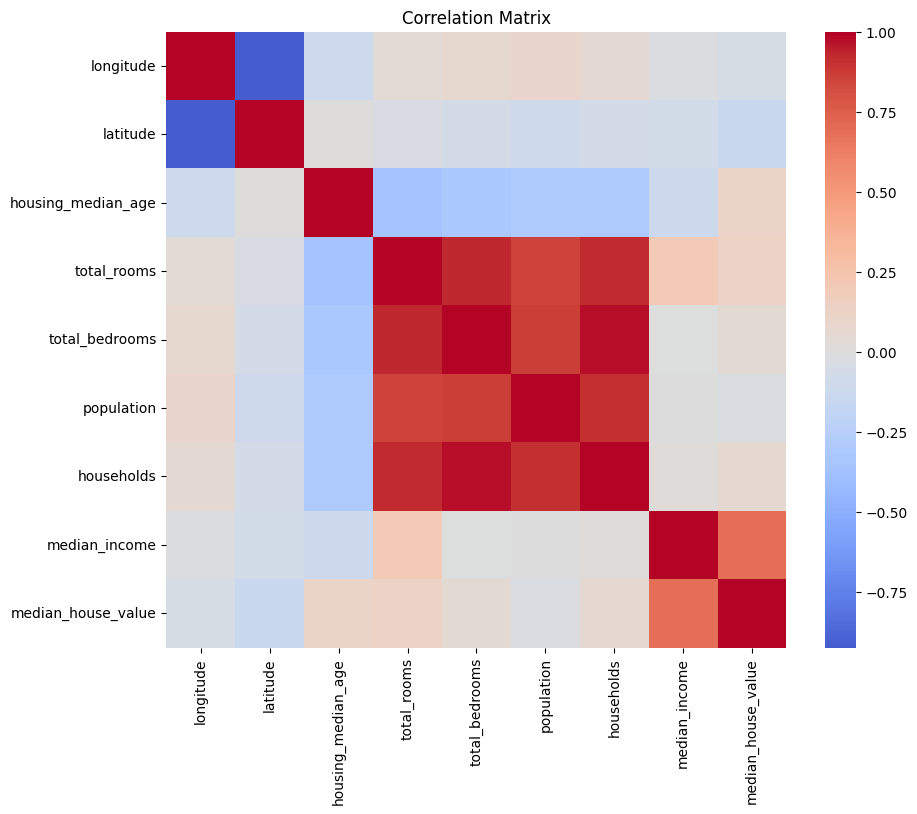

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()


In [40]:
num_features = [
    "median_income",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "latitude",
    "longitude",
    "population"
]
print(num_features)


['median_income', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'latitude', 'longitude', 'population']


In [43]:
#
from pyspark.ml.feature import Imputer

imputer = Imputer(inputCols=num_features,
                  outputCols=num_features)

imputer = imputer.fit(train_df)
train = imputer.transform(train_df)
test = imputer.transform(test_df)

train.show()

+---+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+
| id|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|ocean_proximity|
+---+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+
|  1|  -122.22|   37.86|              21.0|     7099.0|        1106.0|    2401.0|    1138.0|       8.3014|          358500.0|       NEAR BAY|
|  2|  -122.24|   37.85|              52.0|     1467.0|         190.0|     496.0|     177.0|       7.2574|          352100.0|       NEAR BAY|
|  3|  -122.25|   37.85|              52.0|     1274.0|         235.0|     558.0|     219.0|       5.6431|          341300.0|       NEAR BAY|
|  4|  -122.25|   37.85|              52.0|     1627.0|         280.0|     565.0|     259.0|       3.8462|          342200.0|       NEAR BAY|
|  5| 

In [45]:
from pyspark.ml.feature import VectorAssembler

num_vec_ass = VectorAssembler(inputCols=num_features,
                              outputCol='num_features_vec')
train = num_vec_ass.transform(train)
test = num_vec_ass.transform(test)
train.show((5))

+---+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+--------------------+
| id|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|ocean_proximity|    num_features_vec|
+---+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+--------------------+
|  1|  -122.22|   37.86|              21.0|     7099.0|        1106.0|    2401.0|    1138.0|       8.3014|          358500.0|       NEAR BAY|[8.3014,21.0,7099...|
|  2|  -122.24|   37.85|              52.0|     1467.0|         190.0|     496.0|     177.0|       7.2574|          352100.0|       NEAR BAY|[7.2574,52.0,1467...|
|  3|  -122.25|   37.85|              52.0|     1274.0|         235.0|     558.0|     219.0|       5.6431|          341300.0|       NEAR BAY|[5.6431,52.0,1274...|
|  4|  -122.25|   37.8

In [46]:
# select 5 features
train.select('num_features_vec').take(5)

[Row(num_features_vec=DenseVector([8.3014, 21.0, 7099.0, 1106.0, 37.86, -122.22, 2401.0])),
 Row(num_features_vec=DenseVector([7.2574, 52.0, 1467.0, 190.0, 37.85, -122.24, 496.0])),
 Row(num_features_vec=DenseVector([5.6431, 52.0, 1274.0, 235.0, 37.85, -122.25, 558.0])),
 Row(num_features_vec=DenseVector([3.8462, 52.0, 1627.0, 280.0, 37.85, -122.25, 565.0])),
 Row(num_features_vec=DenseVector([4.0368, 52.0, 919.0, 213.0, 37.85, -122.25, 413.0]))]

In [47]:
# data is't normalized thus lets make it to a standard scale
from pyspark.ml.feature import StandardScaler
scaler = StandardScaler(inputCol='num_features_vec',
                      outputCol='scaled_num_features',
                        withStd=True,
                        withMean=True)

scaler = scaler.fit(train)

train = scaler.transform(train)
test = scaler.transform(test)
train.show()

+---+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+--------------------+--------------------+
| id|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|ocean_proximity|    num_features_vec| scaled_num_features|
+---+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+--------------------+--------------------+
|  1|  -122.22|   37.86|              21.0|     7099.0|        1106.0|    2401.0|    1138.0|       8.3014|          358500.0|       NEAR BAY|[8.3014,21.0,7099...|[2.36030634858484...|
|  2|  -122.24|   37.85|              52.0|     1467.0|         190.0|     496.0|     177.0|       7.2574|          352100.0|       NEAR BAY|[7.2574,52.0,1467...|[1.80521760177028...|
|  3|  -122.25|   37.85|              52.0|     1274.0|         235.0|     558.0

In [48]:
train.select('scaled_num_features').take(5)

[Row(scaled_num_features=DenseVector([2.3603, -0.6083, 2.0611, 1.3599, 1.0328, -1.3145, 0.8556])),
 Row(scaled_num_features=DenseVector([1.8052, 1.8518, -0.5405, -0.8325, 1.0281, -1.3245, -0.8177])),
 Row(scaled_num_features=DenseVector([0.9469, 1.8518, -0.6297, -0.7248, 1.0281, -1.3295, -0.7633])),
 Row(scaled_num_features=DenseVector([-0.0085, 1.8518, -0.4666, -0.6171, 1.0281, -1.3295, -0.7571])),
 Row(scaled_num_features=DenseVector([0.0928, 1.8518, -0.7937, -0.7774, 1.0281, -1.3295, -0.8906]))]

In [49]:
from pyspark.ml.feature import StringIndexer

indexer = StringIndexer(inputCol='ocean_proximity',
                        outputCol='ocean_category_index')
indexer = indexer.fit(train)
train = indexer.transform(train)
test = indexer.transform(test)
train.show(5)

+---+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+--------------------+--------------------+--------------------+
| id|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|ocean_proximity|    num_features_vec| scaled_num_features|ocean_category_index|
+---+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+--------------------+--------------------+--------------------+
|  1|  -122.22|   37.86|              21.0|     7099.0|        1106.0|    2401.0|    1138.0|       8.3014|          358500.0|       NEAR BAY|[8.3014,21.0,7099...|[2.36030634858484...|                 3.0|
|  2|  -122.24|   37.85|              52.0|     1467.0|         190.0|     496.0|     177.0|       7.2574|          352100.0|       NEAR BAY|[7.2574,52.0,1467...|[1.80521760177028.

In [50]:
set(train.select('ocean_category_index').collect())

{Row(ocean_category_index=0.0),
 Row(ocean_category_index=1.0),
 Row(ocean_category_index=2.0),
 Row(ocean_category_index=3.0),
 Row(ocean_category_index=4.0)}

In [51]:
# lets do the one hot encoding to this
from pyspark.ml.feature import OneHotEncoder

one_hot_encoder = OneHotEncoder(inputCol='ocean_category_index',
                                outputCol='ocean_category_one_hot')

one_hot_encoder = one_hot_encoder.fit(train)
train = one_hot_encoder.transform(train)
test = one_hot_encoder.transform(test)
train.show(5)

+---+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+--------------------+--------------------+--------------------+----------------------+
| id|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|ocean_proximity|    num_features_vec| scaled_num_features|ocean_category_index|ocean_category_one_hot|
+---+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+--------------------+--------------------+--------------------+----------------------+
|  1|  -122.22|   37.86|              21.0|     7099.0|        1106.0|    2401.0|    1138.0|       8.3014|          358500.0|       NEAR BAY|[8.3014,21.0,7099...|[2.36030634858484...|                 3.0|         (4,[3],[1.0])|
|  2|  -122.24|   37.85|              52.0|     1467.0|         190.0|     496.0|     17

In [53]:
assembler = VectorAssembler(inputCols=['scaled_num_features',
                                       'ocean_category_one_hot'],
                            outputCol='final_features_vector')
train = assembler.transform(train)
test = assembler.transform(test)
train.show(5)


+---+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+--------------------+--------------------+--------------------+----------------------+---------------------+
| id|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|ocean_proximity|    num_features_vec| scaled_num_features|ocean_category_index|ocean_category_one_hot|final_features_vector|
+---+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+--------------------+--------------------+--------------------+----------------------+---------------------+
|  1|  -122.22|   37.86|              21.0|     7099.0|        1106.0|    2401.0|    1138.0|       8.3014|          358500.0|       NEAR BAY|[8.3014,21.0,7099...|[2.36030634858484...|                 3.0|         (4,[3],[1.0])| [2.36030634858484...|


In [55]:
train.select('final_features_vector').take(5)

[Row(final_features_vector=DenseVector([2.3603, -0.6083, 2.0611, 1.3599, 1.0328, -1.3145, 0.8556, 0.0, 0.0, 0.0, 1.0])),
 Row(final_features_vector=DenseVector([1.8052, 1.8518, -0.5405, -0.8325, 1.0281, -1.3245, -0.8177, 0.0, 0.0, 0.0, 1.0])),
 Row(final_features_vector=DenseVector([0.9469, 1.8518, -0.6297, -0.7248, 1.0281, -1.3295, -0.7633, 0.0, 0.0, 0.0, 1.0])),
 Row(final_features_vector=DenseVector([-0.0085, 1.8518, -0.4666, -0.6171, 1.0281, -1.3295, -0.7571, 0.0, 0.0, 0.0, 1.0])),
 Row(final_features_vector=DenseVector([0.0928, 1.8518, -0.7937, -0.7774, 1.0281, -1.3295, -0.8906, 0.0, 0.0, 0.0, 1.0]))]

### Linear Regression Model Training

In [61]:
from pyspark.ml.regression import LinearRegression
lr = LinearRegression(featuresCol='final_features_vector',
          labelCol='median_house_value')
lr = lr.fit(train)
lr

LinearRegressionModel: uid=LinearRegression_4bf103b0c888, numFeatures=11

In [63]:
pred_train_df = lr.transform(train).withColumnRenamed(
    'prediction',
    'predicted_median_house_value'
)
pred_train_df.show(5)

+---+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+--------------------+--------------------+--------------------+----------------------+---------------------+----------------------------+
| id|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|ocean_proximity|    num_features_vec| scaled_num_features|ocean_category_index|ocean_category_one_hot|final_features_vector|predicted_median_house_value|
+---+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+--------------------+--------------------+--------------------+----------------------+---------------------+----------------------------+
|  1|  -122.22|   37.86|              21.0|     7099.0|        1106.0|    2401.0|    1138.0|       8.3014|          358500.0|       NEAR BAY|[8.3014,21.0,7099...|[

### Model Predictions

In [65]:
pred_test_df = lr.transform(test).withColumnRenamed(
    'prediction',
    'predicted_median_house_value'
)
pred_test_df.show(5)

+---+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+--------------------+--------------------+--------------------+----------------------+---------------------+----------------------------+
| id|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|ocean_proximity|    num_features_vec| scaled_num_features|ocean_category_index|ocean_category_one_hot|final_features_vector|predicted_median_house_value|
+---+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+--------------------+--------------------+--------------------+----------------------+---------------------+----------------------------+
|  0|  -122.23|   37.88|              41.0|      880.0|         129.0|     322.0|     126.0|       8.3252|          452600.0|       NEAR BAY|[8.3252,41.0,880....|[

In [66]:
pred_df = pred_test_df.toPandas()
pred_df.head(5)

,id,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,num_features_vec,scaled_num_features,ocean_category_index,ocean_category_one_hot,final_features_vector,predicted_median_house_value
0,0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,"[8.3252, 41.0, 880.0, 129.0, 37.88, -122.23, 3...","[2.3729606705907718, 0.9788246945741829, -0.81...",3.0,"(0.0, 0.0, 0.0, 1.0)","[2.3729606705907718, 0.9788246945741829, -0.81...",413688.248549
1,8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY,"[2.0804, 42.0, 2555.0, 665.0, 37.84, -122.26, ...","[-0.9473632816195446, 1.0581822005701886, -0.0...",3.0,"(0.0, 0.0, 0.0, 1.0)","[-0.9473632816195446, 1.0581822005701886, -0.0...",199734.284515
2,11,-122.26,37.85,52.0,3503.0,752.0,1504.0,734.0,3.2705,241800.0,NEAR BAY,"[3.2705, 52.0, 3503.0, 752.0, 37.85, -122.26, ...","[-0.3145940119030608, 1.8517572605302453, 0.39...",3.0,"(0.0, 0.0, 0.0, 1.0)","[-0.3145940119030608, 1.8517572605302453, 0.39...",254056.918387
3,27,-122.28,37.85,52.0,1898.0,421.0,1102.0,397.0,1.8080,105500.0,NEAR BAY,"[1.808, 52.0, 1898.0, 421.0, 37.85, -122.28, 1...","[-1.0921967822251828, 1.8517572605302453, -0.3...",3.0,"(0.0, 0.0, 0.0, 1.0)","[-1.0921967822251828, 1.8517572605302453, -0.3...",176359.194334
4,30,-122.28,37.84,49.0,1916.0,447.0,863.0,378.0,1.9274,122300.0,NEAR BAY,"[1.9274, 49.0, 1916.0, 447.0, 37.84, -122.28, ...","[-1.028712494514782, 1.6136847425422283, -0.33...",3.0,"(0.0, 0.0, 0.0, 1.0)","[-1.028712494514782, 1.6136847425422283, -0.33...",188761.123093


In [67]:
predictions_and_actuals = pred_test_df[['predicted_median_house_value',
                                        'median_house_value']]

predictions_and_actuals_rdd = predictions_and_actuals.rdd
predictions_and_actuals_rdd.take(5)


Exception ignored in: <function JavaWrapper.__del__ at 0x7e3e8c150e00>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pyspark/ml/wrapper.py", line 53, in __del__
    if SparkContext._active_spark_context and self._java_obj is not None:
                                              ^^^^^^^^^^^^^^
AttributeError: 'LinearRegression' object has no attribute '_java_obj'


[Row(predicted_median_house_value=413688.2485487842, median_house_value=452600.0),
 Row(predicted_median_house_value=199734.28451474893, median_house_value=226700.0),
 Row(predicted_median_house_value=254056.91838742862, median_house_value=241800.0),
 Row(predicted_median_house_value=176359.19433395466, median_house_value=105500.0),
 Row(predicted_median_house_value=188761.1230927289, median_house_value=122300.0)]

In [68]:
predictions_and_actuals_rdd = predictions_and_actuals_rdd.map(tuple)

predictions_and_actuals_rdd.take(5)

[(413688.2485487842, 452600.0),
 (199734.28451474893, 226700.0),
 (254056.91838742862, 241800.0),
 (176359.19433395466, 105500.0),
 (188761.1230927289, 122300.0)]

#### Model Evaluations

In [69]:
from pyspark.mllib.evaluation import RegressionMetrics

metrics = RegressionMetrics(predictions_and_actuals_rdd)

s = '''
Mean Squared Error:      {0}
Root Mean Squared Error: {1}
Mean Absolute Error:     {2}
R**2:                    {3}
'''.format(metrics.meanSquaredError,
           metrics.rootMeanSquaredError,
           metrics.meanAbsoluteError,
           metrics.r2
           )

print(s)

/usr/local/lib/python3.12/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(



Mean Squared Error:      4806744594.862493
Root Mean Squared Error: 69330.69013692632
Mean Absolute Error:     50258.40665222413
R**2:                    0.6349741156259219

